# Amazon (Índia) — Análise de Produtos, Preços e Avaliações

Análise exploratória de ~1.500 produtos da Amazon Índia (dataset do Kaggle). O foco é entender
**como estão distribuídos os produtos por categoria**, **o quanto a Amazon desconta** e se
**desconto alto tem relação com melhor avaliação**.

> Observação: o dataset é de **produtos** (preço, desconto, nota, nº de avaliações) — não há volume
> de vendas. Os preços estão em **rupias (₹)**.


## 1. Setup e carregamento

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv('../amazon.csv')
print('Produtos x colunas:', df.shape)
df[['product_name', 'category', 'discounted_price', 'actual_price',
    'discount_percentage', 'rating', 'rating_count']].head()

Produtos x colunas: (1465, 16)


,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count
0,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269"
1,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994"
2,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928"
3,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363"
4,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905"


## 2. Limpeza

Os campos vêm como texto (com `₹`, `%` e vírgulas de milhar). Converto para número e crio a
**categoria principal** (o primeiro nível da hierarquia de categorias).

In [2]:
def num(col):
    return pd.to_numeric(
        col.astype(str).str.replace('₹', '', regex=False)
           .str.replace(',', '', regex=False).str.replace('%', '', regex=False).str.strip(),
        errors='coerce')

df['preco'] = num(df['discounted_price'])
df['preco_original'] = num(df['actual_price'])
df['desconto_pct'] = num(df['discount_percentage'])
df['nota'] = pd.to_numeric(df['rating'].astype(str).str.strip(), errors='coerce')
df['qtd_avaliacoes'] = num(df['rating_count'])

cat_pt = {
    'Electronics': 'Eletrônicos', 'Computers&Accessories': 'Computadores & Acessórios',
    'Home&Kitchen': 'Casa & Cozinha', 'OfficeProducts': 'Produtos de Escritório',
    'MusicalInstruments': 'Instrumentos Musicais', 'HomeImprovement': 'Reforma & Construção',
    'Health&PersonalCare': 'Saúde & Cuidado Pessoal', 'Toys&Games': 'Brinquedos & Jogos',
    'Car&Motorbike': 'Carro & Moto',
}
df['categoria_principal'] = df['category'].astype(str).str.split('|').str[0].map(lambda c: cat_pt.get(c, c))

df[['categoria_principal', 'preco', 'desconto_pct', 'nota', 'qtd_avaliacoes']].describe().round(2)

,preco,desconto_pct,nota,qtd_avaliacoes
count,1465.00,1465.00,1464.00,1463.00
mean,3125.31,47.69,4.10,18295.54
std,6944.30,21.64,0.29,42753.86
min,39.00,0.00,2.00,2.00
25%,325.00,32.00,4.00,1186.00
50%,799.00,50.00,4.10,5179.00
75%,1999.00,63.00,4.30,17336.50
max,77990.00,94.00,5.00,426973.00


## 3. Visão geral

In [3]:
print(f"Produtos: {len(df):,}")
print(f"Categorias principais: {df['categoria_principal'].nunique()}")
print(f"Nota média: {df['nota'].mean():.2f}")
print(f"Desconto médio: {df['desconto_pct'].mean():.0f}%")
print(f"Preço médio (com desconto): ₹{df['preco'].mean():,.0f}")
print(f"Total de avaliações somadas: {df['qtd_avaliacoes'].sum():,.0f}")

Produtos: 1,465
Categorias principais: 9
Nota média: 4.10
Desconto médio: 48%
Preço médio (com desconto): ₹3,125
Total de avaliações somadas: 26,766,377


## 4. Concentração por categoria

Poucas categorias dominam o catálogo.

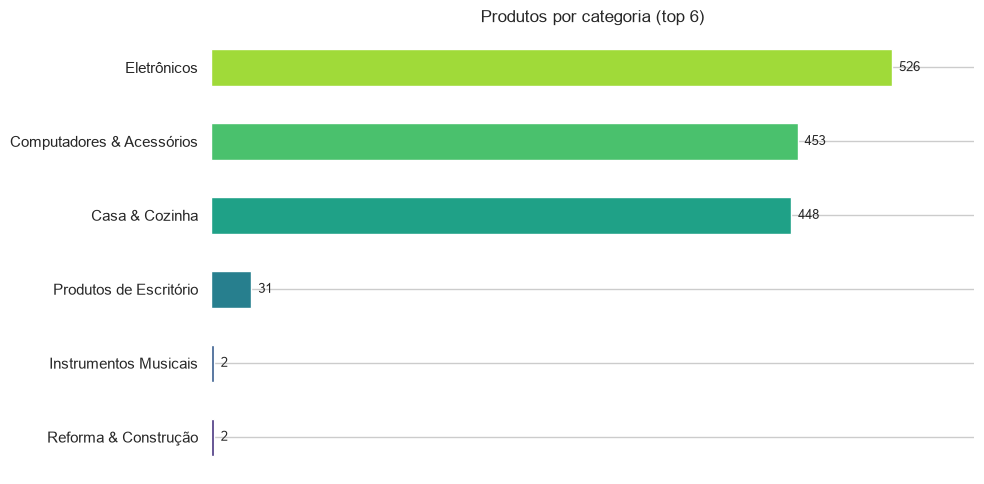

In [4]:
top = df['categoria_principal'].value_counts().head(6).sort_values()
ax = top.plot(kind='barh', color=sns.color_palette('viridis', len(top)))
ax.set_title('Produtos por categoria (top 6)')
ax.set_xlabel(''); ax.set_ylabel('')
for i, v in enumerate(top):
    ax.text(v + top.max() * 0.01, i, f'{v}', va='center', fontsize=9)
ax.set_xticks([]); ax.set_xlim(0, top.max() * 1.12)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.savefig('../imagens/categorias.png', dpi=120)
plt.show()

## 5. Desconto x avaliação 🔑

_Hipótese: desconto agressivo não significa produto melhor avaliado._

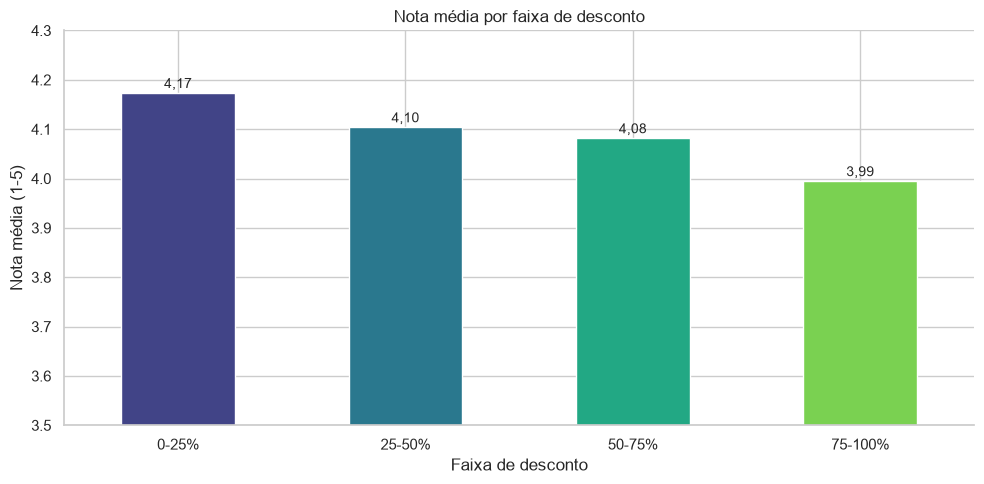

Correlação desconto x nota: -0.155


In [5]:
df['faixa'] = pd.cut(df['desconto_pct'], [0, 25, 50, 75, 100],
                     labels=['0-25%', '25-50%', '50-75%', '75-100%'], include_lowest=True)
m = df.groupby('faixa', observed=True)['nota'].mean()

ax = m.plot(kind='bar', color=sns.color_palette('viridis', len(m)))
ax.set_title('Nota média por faixa de desconto')
ax.set_xlabel('Faixa de desconto'); ax.set_ylabel('Nota média (1-5)')
ax.set_ylim(3.5, 4.3)
for i, v in enumerate(m):
    ax.text(i, v + 0.01, f'{v:.2f}'.replace('.', ','), ha='center', fontsize=10)
plt.xticks(rotation=0); sns.despine()
plt.tight_layout()
plt.savefig('../imagens/desconto_vs_nota.png', dpi=120)
plt.show()

print(f"Correlação desconto x nota: {df['desconto_pct'].corr(df['nota']):.3f}")

## 6. Como a Amazon desconta

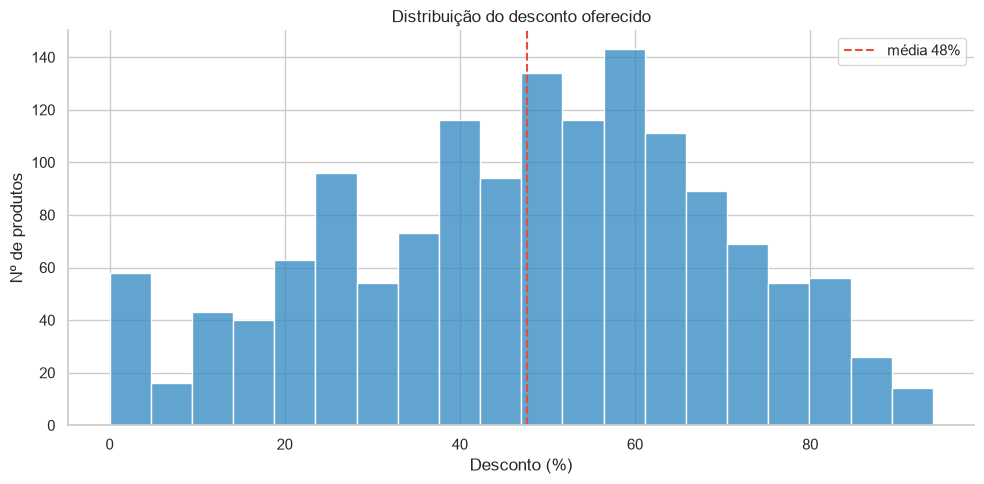

In [6]:
ax = sns.histplot(df['desconto_pct'].dropna(), bins=20, color='#2E86C1')
ax.axvline(df['desconto_pct'].mean(), color='#E74C3C', linestyle='--',
           label=f"média {df['desconto_pct'].mean():.0f}%")
ax.set_title('Distribuição do desconto oferecido')
ax.set_xlabel('Desconto (%)'); ax.set_ylabel('Nº de produtos')
ax.legend(); sns.despine()
plt.tight_layout()
plt.savefig('../imagens/distribuicao_desconto.png', dpi=120)
plt.show()

## 7. Conclusões

- **Catálogo concentrado:** Eletrônicos, Computadores e Casa & Cozinha representam ~97% dos produtos.
- **Desconto é a regra, não a exceção:** desconto médio de ~48%, com boa parte do catálogo entre 40% e 70%.
- **Desconto alto ≠ produto melhor:** a nota média cai de **4,17** (0-25% de desconto) para **3,99** (75-100%),
  com correlação negativa (-0,15). Ou seja, promoção agressiva tende a acompanhar produtos um pouco pior avaliados.
- **Notas comprimidas:** quase tudo fica entre 4,0 e 4,4 — provável viés de sobrevivência (produtos ruins somem do catálogo).

**Recomendações de negócio:** usar o desconto como alavanca com cuidado (não sinaliza qualidade); priorizar
curadoria de avaliação nas categorias que mais descontam (Computadores, Eletrônicos); e olhar além da nota média,
que é pouco discriminante nesse catálogo.